# Overview

This notebook can be used to recreate the analysis and figures of the paper:  
"Probabilistic and Alarm-Based Evaluation of a b-Value-Driven Deep Learning Earthquake Forecast" by Koehler et al. 
https://arxiv.org/abs/2603.03079


The notebook requires preprocessed data and a pretrained model (and possibly an autoencoder). This can be created using the code from this paper:  
https://arxiv.org/abs/2602.12408  
Code:  
https://zenodo.org/doi/10.5281/zenodo.10829447  

Directories likely have to be adjusted to fit your local configuration based on the previous calculations.

<span style="color:red"><b>You will need the datastructure, the autoencoder, and the history of forecasting models createad by code in the zenodo link above!</b></span>  
The autoencoder and model history are provided, the datastrucure has to be created using files 00_Download_ISC and 01_Preprocessing from the zenodo link above, as it is to big to share easily.

# 1. Library & Previous Data Imports

In [2]:
import time
import os
import subprocess
import numpy as np
import h5py
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl

masterdir = 'path_to_your_directory_of_choice'
blockdir = masterdir + 'blockdata/'
modeldir = masterdir + 'models/'
modeldir_ae = modeldir + 'AE/'

## 1.1 Model Selection
Leftover from the parameter search.  
Allows to select other models for analysis. 
If you do not rerun the whole parameter search, you can switch code that relies on that to hardcoded values.

In [3]:
best_margs = [1,3,2,0,0,0]

## 1.2 Data Loading & Names

In [3]:
# In case of multiple models, this function determines the name from margs. In this case, for one set of models, it can return a constant value
def get_run_name(margs):
        return 'Test_d365_r0.60_m4.9_e20_ed14_b32_bce'

In [4]:
run_name = get_run_name(best_margs)

args = {
    'lookback'     : 365, 
    'dr'           : 0.6,
    'maglim'       : '4.9',
    'lossfunction' : 0,
    'epochlen'     : 14,
    'AE'           : True,
}


print('Best Run:')
print(best_margs)
print(run_name)
print(' Loading corresponding Blockdata')


Best Run:
[1, 3, 2, 0, 0, 0]
Test_d365_r0.60_m4.9_e20_ed14_b32_bce
 Loading corresponding Blockdata


In [5]:
f2 = h5py.File(blockdir + 'Tiles_Parameters_0.1.hdf5', 'r')
bval_loc = np.array(f2['b_value_{}_{:4.2f}'.format(args['lookback'], args['dr'])])[:, 150:260, 150:260]
n_eq_avg = np.array(f2['n_eq_{}_{:4.2f}'.format(args['lookback'], args['dr'])])[:, 150:260, 150:260]
maxm_loc = np.array(f2['maxmag'])[:, 150:260, 150:260]
dept_avg = np.array(f2['depth'])[:, 150:260, 150:260]
noeqarray = np.array(f2['NoEQArray_{}_{:4.2f}_{}'.format(args['lookback'], args['dr'], args['maglim'])])[:, 150:228, 150:228]

f2.close()
b_block = np.clip(np.nan_to_num(bval_loc, posinf=2, neginf=0),0,2)

# 2. Load Torch + Models + Functions

In [6]:
import torch

from torch import nn
import torch.nn.functional as F
import torcheval.metrics
from torch.utils.data import Dataset, DataLoader, random_split


In [7]:
if torch.cuda.is_available():
    print('Cuda Available')
else:
    print('No GPU support currently')

device = "cuda" if torch.cuda.is_available() else "cpu"

Cuda Available


In [8]:
def makeAE_PT():
    class Autoencoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv0 = nn.Conv2d(in_channels= 1, out_channels=  4, kernel_size=4)
            self.conv1 = nn.Conv2d(in_channels= 4, out_channels=  8, kernel_size=4)
            self.conv2 = nn.Conv2d(in_channels= 8, out_channels= 16, kernel_size=4)
            self.conv3 = nn.Conv2d(in_channels=16, out_channels= 32, kernel_size=4)
            
            self.tconv3 = nn.ConvTranspose2d(in_channels=32,   out_channels= 16,  kernel_size=4)
            self.tconv2 = nn.ConvTranspose2d(in_channels=16,   out_channels=  8,  kernel_size=4)
            self.tconv1 = nn.ConvTranspose2d(in_channels= 8,   out_channels=  4,  kernel_size=4)
            self.tconv0 = nn.ConvTranspose2d(in_channels= 4,   out_channels=  1,  kernel_size=4)
            
            self.acti = nn.functional.relu

        def forward(self, x):
            y = self.acti(self.conv0(x.view(-1, 1, 32, 32)))
            x = self.acti(self.conv1(y))
            z = self.acti(self.conv2(x))
            x = self.acti(self.conv3(z))
            
            x = self.acti(self.tconv3(x))
            x = self.acti(self.tconv2(x+z))
            x = self.acti(self.tconv1(x))
            x = self.acti(self.tconv0(x+y))
            
            return self.acti(x).view(-1, 32, 32)
    
    return Autoencoder().to(device)


def getAE(filename):
    model_ae = makeAE_PT()
    if device == 'cpu':
        model_ae.load_state_dict(torch.load(modeldir_ae + filename, map_location=torch.device('cpu')))
    else:
        model_ae.load_state_dict(torch.load(modeldir_ae + filename))
    model_ae = model_ae.to(device) 
    model_ae.eval()
    return model_ae

def autoencode(data, autoencoder):
    n = data.shape[0]
    data_ae = torch.tensor([])
    bs = 16
    for i in range(0, n, bs):
        j = min(i+bs, n)
        data_ae = torch.cat(
            (
                data_ae, 
                data[i:j] - autoencoder(
                    data[i:j].to(device)
                ).view(data[i:j].shape).detach().to('cpu'))
        )
        torch.cuda.empty_cache()
    return data_ae

In [9]:
def makeCDN_PT():
    class CDBlock(nn.Module):
        def __init__(self, call, reduce, channels_in, channels_out):
            super(CDBlock, self).__init__()
            
            self.dilation = 2**(call-1)
            self.c_in = channels_in
            self.c_out = channels_out
            self.reduce = reduce
            
            self.conv3d_1 = nn.Conv3d(in_channels=self.c_in,  out_channels=self.c_out, kernel_size=(1,2,2), padding=0, stride=(1,2,2))
            self.conv3d_2 = nn.Conv3d(in_channels=self.c_out, out_channels=self.c_out, kernel_size=(2,1,1), padding='valid', dilation=(self.dilation,1,1))

            self.batch_norm = nn.BatchNorm3d(self.c_out)
            self.acti = nn.functional.leaky_relu
        
        def forward(self, x):
            if self.reduce:
                x = self.conv3d_1(x)
            x = self.conv3d_2(x)
            x = self.acti(self.batch_norm(x))
            return x

    class CDNModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.linear = nn.Linear(in_features=32, out_features=1)
            self.sigmoid =  nn.functional.sigmoid

            self.blocks = nn.ModuleList([
                    CDBlock(1, True ,  1,  2).to(device) ,
                    CDBlock(2, False,  2,  2).to(device) ,
                    CDBlock(3, True ,  2,  4).to(device) ,
                    CDBlock(4, False,  4,  4).to(device) ,
                    CDBlock(5, True ,  4,  8).to(device) ,
                    CDBlock(6, False,  8,  8).to(device) ,
                    CDBlock(7, True ,  8, 16).to(device) ,
                    CDBlock(8, False, 16, 16).to(device) ,
                    CDBlock(9, True , 16, 32).to(device) ,
            ])                

        def forward(self, x):
            x = x[:, None, :,:,:]
            for i, block in enumerate(self.blocks):
                x = block(x)
            x = self.linear(x.view((-1, 32)))
            return torch.squeeze(self.sigmoid(x))
            
    return CDNModel().to(device)     


In [10]:
def get_continuous_dataset(starting_me=0, last_me=148, **kwargs):
    for me in range(starting_me, last_me+1):
        yield DatasetValid(meta_epoch=me, **kwargs)

class DatasetContinuous(Dataset):
    def __init__(self, meta_epoch, loc_x, loc_y, autoencoder, epochlen):
        super(Dataset, self).__init__()

        tstart = meta_epoch*epochlen
        tend = 512+(meta_epoch+1)*epochlen
        
        
        data = torch.tensor(b_block[tstart:tend, loc_x-16:loc_x+16, loc_y-16:loc_y+16], dtype=torch.float32)
            
        if not autoencoder == None:
            self.data = autoencode(data, autoencoder)
        else:
            self.data = data

        #print(self.data.shape)
    def __len__(self):
        return self.data.shape[0]-512

    def __getitem__(self, index):
        return self.data[index:index+512]

In [11]:
class DatasetValidMagNeq(Dataset):
    def __init__(self, meta_epoch, inputlen=512, epochlen=14, minmag=5.0, autoencoder=None):
        super(Dataset, self).__init__()
        
        tend = inputlen+(meta_epoch+1)*epochlen
        
        inxs1 = np.argwhere(maxm_loc[tend:tend+epochlen, 16:-16, 16:-16] >= minmag) # target = 1

        lenEL = inxs1.shape[0]
        
        if lenEL == 0:
            self.is_empty = True 
        elif noeqarray[tend-inputlen:tend-inputlen+epochlen].astype(int).sum() < lenEL:
            self.is_empty = True
        else: 
            self.is_empty =  False
            self.lastlen = lenEL

        data_valid = np.array([b_block[inx[0]+tend-inputlen:inx[0]+tend, inx[1]:inx[1]+32, inx[2]:inx[2]+32] for inx in inxs1])

        self.data_mag = torch.tensor([maxm_loc[tend:tend+epochlen, 16:-16, 16:-16][inx[0], inx[1], inx[2]] for inx in inxs1])
        self.data_neq = torch.tensor([n_eq_avg[tend:tend+epochlen, 16:-16, 16:-16][inx[0], inx[1], inx[2]] for inx in inxs1])
        
        data_valid = torch.from_numpy(data_valid).to(torch.float32)
        
        if not autoencoder == None:
            self.data = autoencode(data_valid, autoencoder)
        else:
            self.data = data_valid
                        
    def __len__(self):
        return len(self.data_neq)

    def __getitem__(self, index):
        return self.data[index], self.data_neq[index], self.data_mag[index]

In [12]:
AE_name = 'AE_parametersearch_conv_8e-5_100k_64_relu_d{:03d}_r{:4.2f}_m{}.pth'.format(args['lookback'], args['dr'], args['maglim'])
model_ae = getAE(AE_name)

In [16]:
def calculateParamValid(margs):
    args = {
        'lookback'     : [150, 365, 730][margs[0]], 
        'dr'           : [0.15, 0.25, 0.35, 0.6][margs[1]],
        'maglim'       : ['4.0', '4.5', '4.9', 'VAL'][margs[2]],
        'lossfunction' : [0, 1][margs[3]],
        'epochlen'     : [14, 30, 50][margs[4]],
        'AE'           : [True, False][margs[5]],
    }
    end_me = 589
    
    path = modeldir + 'checkpoints_Test_d365_r0.60_m4.9_e20_ed14_b32_bce/'
    
    #AE_name = 'AE_parametersearch_conv_8e-5_100k_64_relu_d{:03d}_r{:4.2f}_m{}.pth'.format(args['lookback'], args['dr'], args['maglim'])
    #model_ae = getAE(AE_name)
    model_ae = None
        
    model = makeCDN_PT()
    print(path)
    result_list = []
    for me in range(484, end_me):
        fname = path + 'classifier_{:03d}.pt'.format(me)
        if os.path.isfile(fname):
            model.load_state_dict(torch.load(fname))
            print(' Read new model in MetaEpoch {:>3d}'.format(me), end='')
        else:
            print(' No new model in MetaEpoch {:>3d}  '.format(me), end='')
        vmndataset = DatasetValidMagNeq(me, autoencoder=model_ae)
        if vmndataset.is_empty: 
            print( ' Dataset is empty')#, end = '\r')
            continue
        else:
            print(' Dataset is not empty')#, end='\r')
            
        validmagneqloader = DataLoader(vmndataset, batch_size=16, shuffle=False)
        
        predict_list = []
        mag_list = []
        neq_list = []

        
        model.eval()        
        for data, neq, mag in validmagneqloader:
            data = data.to(device)
            preds = model(data)
            #print(preds)
            if data.shape[0] > 1:
                predict_list.extend(preds.detach().tolist())
            else:
                predict_list.append(preds.detach().cpu())

            mag_list.extend(mag)
            neq_list.extend(neq)

        result_list.append([me, predict_list, mag_list, neq_list])
        print(f' len(predict_list) = {len(predict_list)}', end='\r')

    return result_list 

## 2.1 Calculate Validation Output
This variable is requires for ETAS output in section 6

In [ ]:
results_validmagneq = calculateParamValid(best_margs)

In [33]:
with open('results_validmagneq_P2.pkl', 'wb') as filehandler:
    pickle.dump(results_validmagneq, filehandler)

# 3. Baseline Model

In [17]:
baseline = np.zeros((11, 110, 110))
for i, m in enumerate(np.arange(3, 8.5, 0.5)):
    baseline[i] = np.logical_and(maxm_loc[:7302]>=m, maxm_loc[:7302]<(m+0.5)).sum(axis=0)
baseline /= 7302.0

baseline5 = (maxm_loc[:7302]>=5.0).sum(axis=0)/7302.0

## 3.1 Calculate the model ouput for the whole training data :|

In [12]:
def autoencode_big(data, autoencoder):
    n = data.shape[0]
    data_ae = []
    bs = 64
    print('')
    for i in range(0, n, bs):
        j = min(i+bs, n)
        data_ae.append(
                data[i:j] - autoencoder(
                    data[i:j].to(device)
                ).view(data[i:j].shape).detach().to('cpu')
        )
        
        torch.cuda.empty_cache()
        print(f'  Autoencoding... {i//bs} of {n//bs}', end='\r')
    data_ae = torch.stack(data_ae).view(-1, 512, 32, 32)
    return data_ae

def autoencode_big2(data, autoencoder, batch_size=128, device='cuda', empty_cache_every=10):
    n = data.shape[0]
    results = []
    data_ae = torch.empty((n, 512, 32, 32), dtype=data.dtype)
    print(f' which has {n} locations')


    with torch.no_grad():  # no gradient tracking
        for i in range(0, n, batch_size):
            j = min(i+batch_size, n)
            batch = data[i:j].to(device, non_blocking=True)
            recon = autoencoder(batch).view(-1, 512, 32, 32)

            #print(batch.shape, recon.shape)
            diff = (batch - recon).detach().cpu()  # move back to CPU immediately
            
            data_ae[i:j].copy_(diff)
            
            if (i // batch_size) % empty_cache_every == 0:
                torch.cuda.empty_cache()

            print(f'  Autoencoding... {i//batch_size} of {n//batch_size}', end='\r')

    return data_ae

class DatasetTest_Full(Dataset):
    def __init__(self, meta_epoch, inputlen=512, epochlen=14, minmag=5.0, autoencoder=None):
        super(Dataset, self).__init__()
        
        tend = inputlen+(meta_epoch+1)*epochlen

        inxs_neq = np.argwhere(n_eq_avg[tend:tend+epochlen, 16:-16, 16:-16] >= 10)
        inxs_mag = np.argwhere(maxm_loc[tend:tend+epochlen, 16:-16, 16:-16] >= minmag)

        combined = np.vstack((inxs_neq, inxs_mag))

        inxs1 = np.unique(combined, axis=0)

        lenEL = inxs1.shape[0]
        
        if lenEL == 0:
            self.is_empty = True 
        else: 
            self.is_empty =  False
            self.lastlen = lenEL

        data_valid = np.array([b_block[inx[0]+tend-inputlen:inx[0]+tend, inx[1]:inx[1]+32, inx[2]:inx[2]+32] for inx in inxs1])

        self.data_mag = torch.tensor([maxm_loc[tend:tend+epochlen, 16:-16, 16:-16][inx[0], inx[1], inx[2]] for inx in inxs1])
        self.data_neq = torch.tensor([n_eq_avg[tend:tend+epochlen, 16:-16, 16:-16][inx[0], inx[1], inx[2]] for inx in inxs1])
        self.inxs = torch.tensor(inxs1)
        
        data_valid = torch.from_numpy(data_valid).to(torch.float32)
        
        if not autoencoder == None:
            self.data = autoencode_big2(data_valid, autoencoder)
        else:
            self.data = data_valid
                        
    def __len__(self):
        return len(self.data_neq)

    def __getitem__(self, index):        
        return self.data[index], self.data_neq[index], self.data_mag[index], self.inxs[index]

In [13]:
def calculate_fullblock(margs, start_me=484, end_me=613):
    args = {
        'lookback'     : [150, 365, 730][margs[0]], 
        'dr'           : [0.15, 0.25, 0.35, 0.6][margs[1]],
        'maglim'       : ['4.0', '4.5', '4.9', 'VAL'][margs[2]],
        'lossfunction' : [0, 1][margs[3]],
        'epochlen'     : [14, 30, 50][margs[4]],
        'AE'           : [True, False][margs[5]],
    }
    
    path, name = getPath(margs)
    if 'AETrue' in name:
        AE_name = 'AE_parametersearch_conv_8e-5_100k_64_relu_d{:03d}_r{:4.2f}_m{}.pth'.format(args['lookback'], args['dr'], args['maglim'])
        model_ae = getAE(AE_name)
    else:
        model_ae = None
        
    model = makeCDN_PT()
    
    result_list_real = []
    result_list_smaller = []

    
    for me in range(start_me, end_me+1):
        fname = path + 'classifier_{:03d}.pt'.format(me)
        if os.path.isfile(fname):
            model.load_state_dict(torch.load(fname))
            print(' Read new model in MetaEpoch {:>3d}'.format(me), end='')
        else:
            print('   No new model in MetaEpoch {:>3d}'.format(me), end='')
            
        test_dataset    = DatasetTest_Full(             me, epochlen=args['epochlen'], autoencoder=model_ae)
        me_block = np.zeros((args['epochlen'], 78, 78))*np.nan
        print('    Dataset Loaded!')
        
        if not test_dataset.is_empty:    
            fullloader = DataLoader(test_dataset, batch_size=64, shuffle=False)
            lcc = 0
            model.eval()        
            for data, neq, mag, inx in fullloader:
                data = data.to(device)
                preds = model(data).detach().cpu()

                if inx.shape[0]>1:
                    for i, txy in enumerate(inx):
                        me_block[txy[0], txy[1], txy[2]] = preds[i]
                else:
                    me_block[inx[0,0], inx[0,1], inx[0,2]] = preds.item()
                print(f'  Processing... {lcc} of {len(fullloader)}', end='\r')
                lcc += 1
        np.save('testset_block_P2/output_me_{}.npy'.format(me), me_block)


In [14]:
calculate_fullblock(best_margs, start_me=484, end_me=613) # This needs ~400GB Ram (no memory leak)

 Read new model in MetaEpoch 484    Dataset Loaded!


/home/jkoehler/ENVS/forecasting_venv/lib/python3.8/site-packages/torch/nn/modules/conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv3d(


   No new model in MetaEpoch 485    Dataset Loaded!
   No new model in MetaEpoch 486    Dataset Loaded!
   No new model in MetaEpoch 487    Dataset Loaded!
   No new model in MetaEpoch 488    Dataset Loaded!
   No new model in MetaEpoch 489    Dataset Loaded!
 Read new model in MetaEpoch 490    Dataset Loaded!
 Read new model in MetaEpoch 491    Dataset Loaded!
   No new model in MetaEpoch 492    Dataset Loaded!
 Read new model in MetaEpoch 493    Dataset Loaded!
   No new model in MetaEpoch 494    Dataset Loaded!
 Read new model in MetaEpoch 495    Dataset Loaded!
   No new model in MetaEpoch 496    Dataset Loaded!
   No new model in MetaEpoch 497    Dataset Loaded!
   No new model in MetaEpoch 498    Dataset Loaded!
 Read new model in MetaEpoch 499    Dataset Loaded!
   No new model in MetaEpoch 500    Dataset Loaded!
 Read new model in MetaEpoch 501    Dataset Loaded!
 Read new model in MetaEpoch 502    Dataset Loaded!
 Read new model in MetaEpoch 503    Dataset Loaded!
   No new mo

In [63]:
filenames = [f'testset_block_P2/output_me_{me}.npy' for me in range(484, 614)]
arrays = [np.load(fname) for fname in filenames]
model_output_testset = np.concatenate(arrays, axis=0)


(1092, 78, 78)

## 4.2  Brier Score

In [54]:
def calculate_brier_score(background, forecast, observation, cmask=None, verbose=True):

    mask = ~np.isnan(forecast)
    if cmask is not None:
        mask = np.logical_and(mask, cmask)
    
    # Compute Brier Scores
    brier_model = np.mean((forecast - observation)[mask] ** 2)
    brier_background = np.mean((background - observation)[mask] ** 2)
    
    # Compute Brier Skill Score
    bss = 1 - (brier_model / brier_background)

    sel = np.logical_and(brier_model == 0, brier_background == 0)
    
    if type(bss) == type(np.array([2.0])):
        bss[sel] = 0
    elif sel:
        bss = 0
        
    
    if verbose:
        print("Brier Score (model):", brier_model)
        print("Brier Score (background):", brier_background)
        print("Brier Skill Score:", bss)

    return bss

In [55]:
class BrierScore():
    def __init__(self):
        self.brier_model_sum = 0
        
        self.brier_background_sum = 0
        
        self.item_count = 0
    
    def calculate_bs(self, background, forecast, observation, cmask=None):
        mask = ~np.isnan(forecast)
        if cmask is not None:
            mask = np.logical_and(mask, cmask)
        
        # Compute Brier Scores
        self.brier_model_sum += np.sum((forecast - observation)[mask] ** 2)
        self.brier_background_sum += np.sum((background - observation)[mask] ** 2)
        self.item_count += np.sum(mask)

    def get_bss(self, verbose=False):
        bss = 1 - (self.brier_model_sum / self.brier_background_sum)
        
        brier_model      = self.brier_model_sum      / self.item_count
        brier_background = self.brier_background_sum / self.item_count
        
        if verbose:
            print("Brier Score (model):", brier_model)
            print("Brier Score (background):", brier_background)
            print("Brier Skill Score:", bss)

        return bss
    

# 4 Doing all this for the 4.9 Model so I can keep the code above
## 4.1 Empirical Rescaling

In [45]:
baseline = np.zeros((11, 110, 110))
for i, m in enumerate(np.arange(3, 8.5, 0.5)):
    baseline[i] = np.logical_and(maxm_loc[:7302]>=m, maxm_loc[:7302]<(m+0.5)).sum(axis=0)
baseline /= 7302.0

baseline5 = (maxm_loc[:7302]>=5.0).sum(axis=0)/7302.0

In [46]:
tend = 512+(484+1)*14
# 1461 is for the 4 years
mot_neq = n_eq_avg[tend:tend+1461, 16:-16, 16:-16]
mot_tgt = maxm_loc[tend:tend+1461, 16:-16, 16:-16] >= 5.0
mot_baseline5 = baseline5[16:-16, 16:-16]

In [47]:
mot_neq.max()

32767

In [48]:
filenames = [f'testset_block/output_me_{me}.npy' for me in range(400, 484)]
arrays = [np.load(fname) for fname in filenames]
model_output_trainset = np.concatenate(arrays, axis=0)

print(model_output_trainset.shape)

eq_on_day = (maxm_loc >= 5.0).sum(axis=(1,2))

for i in range(2000, 7302):
    if eq_on_day[i:7302].sum() < 533: 
        print(i)
        break
        
(4412-512)/14

(1176, 78, 78)
4412


278.57142857142856

In [49]:
me_start = 400
tstart = 512+(me_start)*14
tend = 512+(484)*14

mot_neq_train = n_eq_avg[tstart:tend, 16:-16, 16:-16]
mot_tgt_train = maxm_loc[tstart:tend, 16:-16, 16:-16] >= 5.0
mot_baseline5 = baseline5[16:-16, 16:-16]

motrain_output = model_output_trainset[model_output_trainset.shape[0]-mot_tgt_train.shape[0]:]

In [50]:
scale_arr = np.logspace(-6, 0, 61)
neq_th_arr = np.logspace(1, 4.5, 36)

In [93]:
def get_bss_instance(me_start, me_end, folder='testset_block'):

    filenames = [folder + f'/output_me_{me}.npy' for me in range(me_start, me_end+1)]
    arrays = [np.load(fname) for fname in filenames]
    model_output_fset = np.concatenate(arrays, axis=0)        
    
    tstart = 512+(me_start)*14
    tend = 512+(me_end+1)*14
    
    f_neq = n_eq_avg[tstart:tend, 16:-16, 16:-16]
    f_tgt = maxm_loc[tstart:tend, 16:-16, 16:-16] >= 5.0
    f_baseline5 = baseline5[16:-16, 16:-16]
    f_output = model_output_fset
    
    bss_arr = np.array(
        [
            np.array([calculate_brier_score(f_baseline5, f_output*scale, f_tgt, cmask=f_neq>neq_th, verbose=False) 
                      for neq_th in neq_th_arr]) / scale
        for scale in scale_arr
        ]
    )
    return bss_arr

In [ ]:
def get_bss_instance_logits(me_start, me_end, folder='testset_block'):
    def logits_add(p1, p2):
        eps = 1e-12
        p1, p2 = np.clip(p1, eps, 1 - eps), np.clip(p2, eps, 1 - eps)
        x = np.log(p1 / (1-p1)) + np.log(p2 / (1-p2))
        return 1 / (1+np.exp(-x))
    
    filenames = [folder + f'/output_me_{me}.npy' for me in range(me_start, me_end+1)]
    arrays = [np.load(fname) for fname in filenames]
    model_output_fset = np.concatenate(arrays, axis=0)        
    
    tstart = 512+(me_start)*14
    tend = 512+(me_end+1)*14
    
    f_neq = n_eq_avg[tstart:tend, 16:-16, 16:-16]
    f_tgt = maxm_loc[tstart:tend, 16:-16, 16:-16] >= 5.0
    f_baseline5 = baseline5[16:-16, 16:-16]
    f_output = model_output_fset
    
    bss_arr = np.array(
        [
            np.array([calculate_brier_score(f_baseline5, logits_add(f_output, scale), f_tgt, cmask=f_neq>neq_th, verbose=False) 
                      for neq_th in neq_th_arr]) / scale
        for scale in scale_arr
        ]
    )
    return bss_arr

In [52]:
mot_neq_count = np.array([(mot_neq_train>neq_th).sum() for neq_th in neq_th_arr])

# I think the next line is not longer necessary, see uf anything breaks
#bss_train_org = get_bss_instance(me_start=400, me_end=484, folder='testset_block')

# This is necessary for calculating the baseline rescaling
tend = 512+(484+1)*14
eq_bl = (maxm_loc[512:tend, 16:-16, 16:-16] > 5).sum()
aneq_bl = np.array([(n_eq_avg[512:tend, 16:-16, 16:-16] > k).sum() for k in neq_th_arr])
rate_bl = eq_bl / aneq_bl

In [94]:
bss_train_49 = get_bss_instance(me_start=400, me_end=484, folder='testset_block_maglim49')
print('Finished 1/2')
bss_test_49  = get_bss_instance(me_start=485, me_end=589, folder='testset_block_P2')
print('Finished 2/2')
with open('bss_test_arrays.npz', 'wb') as fo:
    np.savez(fo, bss_train_49=bss_train_49, bss_test_49=bss_test_49)

In [58]:
bss_train_logit = get_bss_instance_logits(me_start=400, me_end=484, folder='testset_block_maglim49')
print('Finished 1/2')
bss_test_logit  = get_bss_instance_logits(me_start=485, me_end=589, folder='testset_block_P2')
print('Finished 2/2')
with open('bss_test_arrays_logits.npz', 'wb') as fo:
    np.savez(fo, bss_train_logit=bss_train_logit, bss_test_logit=bss_test_logit)

/tmp/ipykernel_1614228/2246421228.py:3: RuntimeWarning: divide by zero encountered in divide
  x = np.log(p1 / (1-p1)) + np.log(p2 / (1-p2))
/tmp/ipykernel_1614228/2246421228.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  x = np.log(p1 / (1-p1)) + np.log(p2 / (1-p2))


Finished 1/2
Finished 2/2


In [88]:
#with open('bss_test_arrays.npz', 'wb') as fo:
#    np.savez(fo, bss_train_49=bss_train_49, bss_test_49=bss_test_49)

fi = np.load('bss_test_arrays.npz')
bss_train_49 = fi['bss_train_49']
bss_test_49  = fi['bss_test_49']

In [80]:
from scipy.interpolate import interp1d

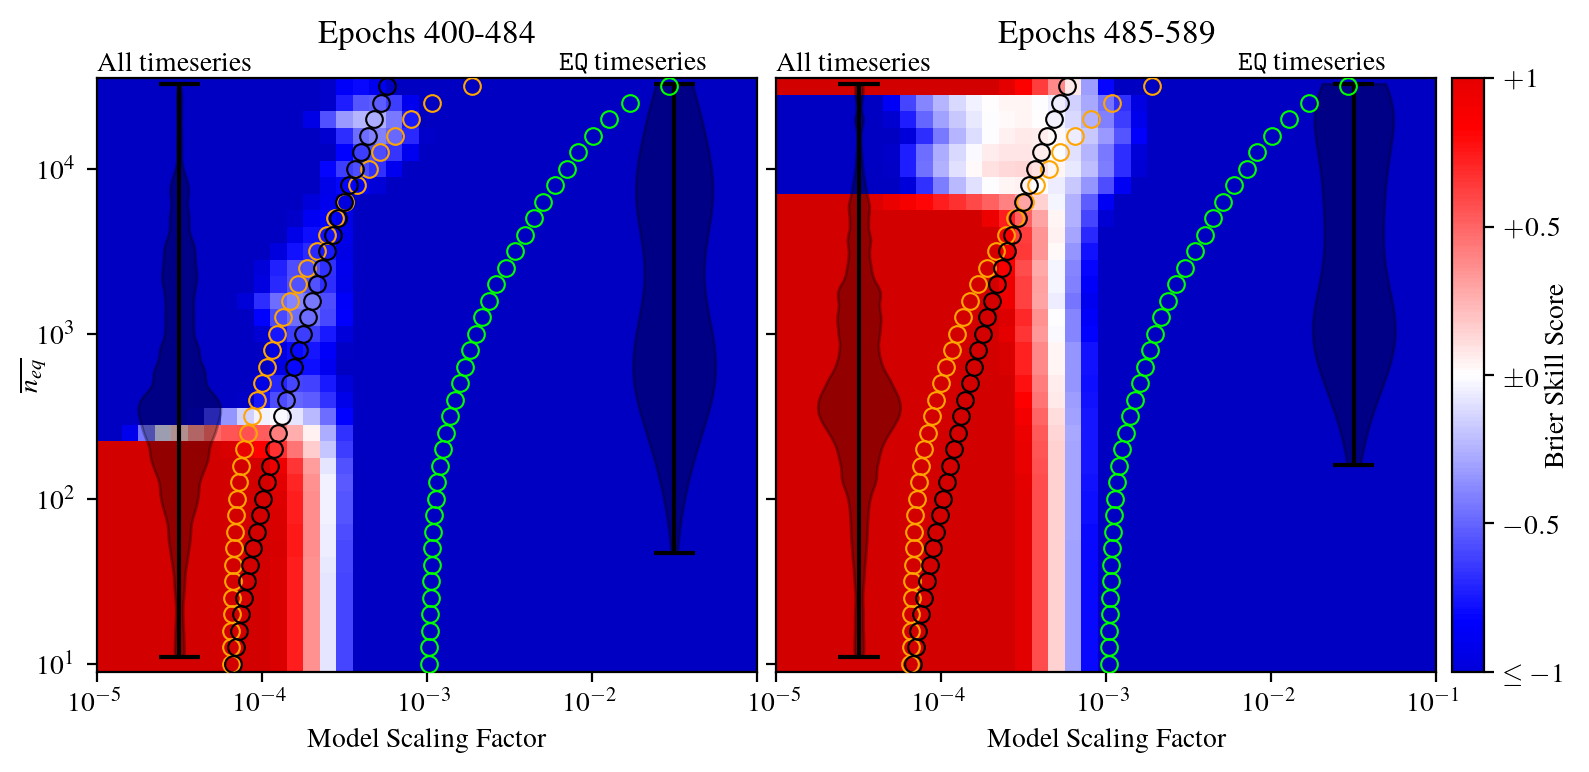

In [96]:
def CBPlacer(ax, top=False):
    x0 = ax.get_position().x1+0.01
    x1 = 0.02
    y0 = ax.get_position().y0
    y1 = ax.get_position().y1-y0
    return [x0, y0, x1, y1]

fig, ax = plt.subplots(1,2, figsize=(8,4), dpi=200, sharey=True)
plt.tight_layout(rect=(0.01, 0, 0.93, 1))
plt.subplots_adjust(wspace=0.03, hspace=0.03)

cmap = mpl.colormaps['seismic']

alim = np.array([-1, 1]) * 1
vlim = np.array([-1, 1]) * 1.5

ax[1].imshow(np.clip(bss_test_49.T, a_min=alim[0], a_max=alim[1]), cmap='seismic', vmin=vlim[0], vmax=vlim[1], origin='lower')
ax[1].set_xlabel('Model Scaling Factor')
ax[1].set_xticks(np.arange(0, len(scale_arr), 10))
ax[1].set_xticklabels([r'$10^{{{}}}$'.format(int(np.log10(s))) for s in scale_arr[::10]])


C = mot_tgt_train.sum()/(mot_neq_train>10).sum() / np.mean((1/mot_neq_train[mot_neq_train>10]))
lprime = np.log10((C * rate_bl)/(1-C*rate_bl))
xloc_bayes = 1 / (1+np.exp(-lprime))
xloc_bayes = np.log10(xloc_bayes) * 10 + 60 # Transformation for figure

C = C*1.7e-3
lprime = np.log10((C * rate_bl)/(1-C*rate_bl))
xloc_bayes_em = 1 / (1+np.exp(-lprime))
xloc_bayes_em = np.log10(xloc_bayes_em) * 10 + 60 # Transformation for figure



xloc2 = np.log10(
    np.exp(np.power(neq_th_arr, 0.12)) * 1.8e-5 # <---------- Recalibrating Function, use this to rescale baseline
)*10+60


ax[1].plot(xloc_bayes, np.arange(len(neq_th_arr)), marker='o', lw=0, markerfacecolor='none', mec='lime', mew=0.75, zorder=10)
ax[1].plot(xloc_bayes_em, np.arange(len(neq_th_arr)), marker='o', lw=0, markerfacecolor='none', mec='orange', mew=0.75, zorder=10)
ax[1].plot(xloc2, np.arange(len(neq_th_arr)), marker='o', lw=0, markerfacecolor='none', mec='k', mew=0.75, zorder=10)

ax[0].set_ylabel(r'$\overline{n_{eq}}$', labelpad=-2)
ax[1].set_yticks(np.arange(0, len(neq_th_arr), 10))
ax[1].set_yticklabels([r'$10^{{{}}}$'.format(int(np.log10(s))) for s in neq_th_arr[::10]])

ax[1].set_xlim([10, 50])
ax[1].set_ylim([-0.5, 35.5])
#ax[1].set_ylim([-0.5, 40])


#######################################

ax[0].imshow(np.clip(bss_train_49.T, a_min=alim[0], a_max=alim[1]), cmap='seismic', vmin=vlim[0], vmax=vlim[1], origin='lower')
ax[0].set_xlabel('Model Scaling Factor')
ax[0].set_xticks(np.arange(0, len(scale_arr), 10))
ax[0].set_xticklabels([r'$10^{{{}}}$'.format(int(np.log10(s))) for s in scale_arr[::10]][:-2] + ['']*2)

ax[0].plot(xloc_bayes,  np.arange(len(neq_th_arr)), marker='o', lw=0, markerfacecolor='none', mec='lime', mew=0.75, zorder=10)
ax[0].plot(xloc_bayes_em, np.arange(len(neq_th_arr)), marker='o', lw=0, markerfacecolor='none', mec='orange', mew=0.75, zorder=10)
ax[0].plot(xloc2, np.arange(len(neq_th_arr)), marker='o', lw=0, markerfacecolor='none', mec='k', mew=0.75, zorder=10)


ax[0].set_xlim([10, 50])


def set_vp_color(vp, color):
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_edgecolor(color)

    if 'cmedians' in vp:
        vp['cmedians'].set_color(color)
    
    for partname in ['cbars', 'cmins', 'cmaxes']:
        if partname in vp:
            vp[partname].set_color(color)

vp = ax[1].violinplot(np.log10(mot_neq[mot_tgt])*10-10, positions=[45], widths=5)  
set_vp_color(vp, 'k')

vp = ax[1].violinplot(np.log10(mot_neq[mot_neq>10])*10-10, positions=[15], widths=5)
set_vp_color(vp, 'k')

vp = ax[0].violinplot(np.log10(mot_neq_train[mot_tgt_train])*10-10, positions=[45], widths=5)  
set_vp_color(vp, 'k')

vp = ax[0].violinplot(np.log10(mot_neq_train[mot_neq_train>10])*10-10, positions=[15], widths=5)
set_vp_color(vp, 'k')


ax[0].set_title('Epochs 400-484', pad=13)
ax[1].set_title('Epochs 485-589', pad=13)

for a in ax:
    a.text(10, 36, 'All timeseries')
    a.text(38, 36, r'$\mathtt{EQ}$ timeseries')


rescaled_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'seismic_rescaled',
    cmap(np.linspace(0.2, 0.8, 256))
)

axc = fig.add_axes(CBPlacer(ax[1]))
norm = mpl.colors.Normalize(vmin=-10, vmax=10)
cb1 = mpl.colorbar.ColorbarBase(axc, cmap=rescaled_cmap, norm=norm, orientation='vertical')
cb1.set_label('Brier Skill Score', labelpad=-8)

cbticks = list(np.linspace(-10, 10, 5))
cb1.set_ticks(cbticks)
cb1.set_ticklabels(['$\leq-1$', ' $-0.5$', ' $\pm0$', ' $+0.5$', ' $+1$'])


In [ ]:
from scipy.interpolate import interp1d
import numpy as np

def make_interpolator(x_vals, y_vals, kind='cubic'):
    """
    Returns a function that interpolates y for a given x using the provided data.

    Parameters:
    - x_vals: array-like, x data points
    - y_vals: array-like, y data points
    - kind: str, interpolation type ('linear', 'quadratic', 'cubic', etc.)

    Returns:
    - interp_func: function that takes new x value(s) and returns interpolated y value(s)
    """
    interpolator = interp1d(x_vals, y_vals, kind=kind, bounds_error=False, fill_value="extrapolate")
    return interpolator

scale_from_neq = make_interpolator(neq_th_arr, rate_bl)
scale_from_neq2 = make_interpolator(neq_th_arr, np.exp(np.power(neq_th_arr, 0.142)) * 2.5e-5)



## 4.2 Rescaling Using Logits

In [258]:
tend = 512+(484+1)*14

neq_block_rs = n_eq_avg[:tend]
eq_loc = maxm_loc[:tend] >= 5.0

In [259]:
neq_block_rs[eq_loc]

array([1192.,   55., 1206., ..., 8464., 6496., 1273.], dtype=float16)

In [302]:
bins = np.logspace(0, 5, 51).round(0).astype(int)

counts_eq, _  = np.histogram(neq_block_rs[eq_loc],   bins=bins)
counts_all, _ = np.histogram(neq_block_rs.flatten(), bins=bins)

xticks = np.arange(len(bins)-1)

/tmp/ipykernel_1910930/1006502257.py:8: RuntimeWarning: invalid value encountered in divide
  ax[2].plot(xticks, counts_eq/counts_all)


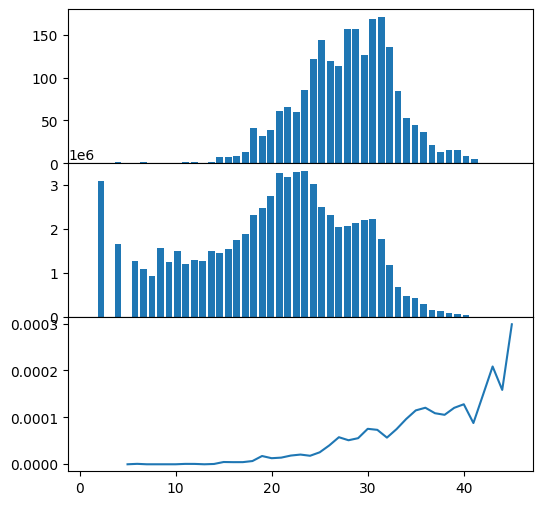

In [303]:
fig, ax = plt.subplots(3,1, figsize=(6, 6))

plt.subplots_adjust(hspace=0)


ax[0].bar(xticks, counts_eq)
ax[1].bar(xticks, counts_all)
ax[2].plot(xticks, counts_eq/counts_all)

In [556]:
from scipy.interpolate import UnivariateSpline, PchipInterpolator, interp1d
from scipy.special import expit

def make_logit_rescaler_from_raw(neq_A, neq_all, train_prior=0.5, n_bins=51, smooth=20.0):
    """
    Build a logit rescaling function from raw neq values.

    Parameters
    ----------
    neq_A : np.ndarray
        Array of neq values for class A samples.
    neq_all : np.ndarray
        Array of neq values for all samples.
    train_prior : float
        Training prior probability of class A. Default=0.5.
    n_bins : int
        Number of bins to use for estimating priors.
    smooth : float
        Smoothing factor for spline. Larger = smoother.

    Returns
    -------
    rescale_fn : callable
        Function that takes (logits, neq) and returns corrected probabilities.
    """

    # Bin in log10 space
    bins = np.logspace(1, np.log10(np.max(neq_all)), n_bins+1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])  # geometric mean center

    # Histogram counts
    count_all, _ = np.histogram(neq_all, bins=bins)
    count_A, _   = np.histogram(neq_A, bins=bins)

    # Empirical class-A rates
    with np.errstate(divide='ignore', invalid='ignore'):
        rates = np.divide(count_A, count_all, out=np.zeros_like(count_A, dtype=float), where=count_all>0)

    # Fit smoothing spline in log10 space
    mask = count_all > 0
    
    interpolator = UnivariateSpline(np.log10(bin_centers[mask]), rates[mask], k=5, s=smooth)
    #interpolator = interp1d(np.log10(bin_centers[mask]), rates[mask], bounds_error=False, fill_value=(rates[mask][0], rates[mask][-1]))
    #interpolator = PchipInterpolator(np.log10(bin_centers[mask]), rates[mask], extrapolate=True)

    
    logit_train_prior = np.log(train_prior / (1 - train_prior))

    def rescale_fn(p, neq, scale=0):
        logits = np.log(p / (1 - p))
        true_prior = np.clip(interpolator(np.log10(neq)), 1e-12, 1 - 1e-12)
        logit_true_prior = np.log(true_prior / (1 - true_prior))
        corrected_logit = logits + (logit_true_prior - logit_train_prior) + scale
        return expit(corrected_logit)

    return rescale_fn

In [557]:
rescaler_scratch = make_logit_rescaler_from_raw(neq_block_rs[eq_loc],neq_block_rs.flatten(), n_bins=50, smooth=None)

/tmp/ipykernel_1910930/264939529.py:4: RuntimeWarning: invalid value encountered in divide
  plt.plot(counts_eq/counts_all)


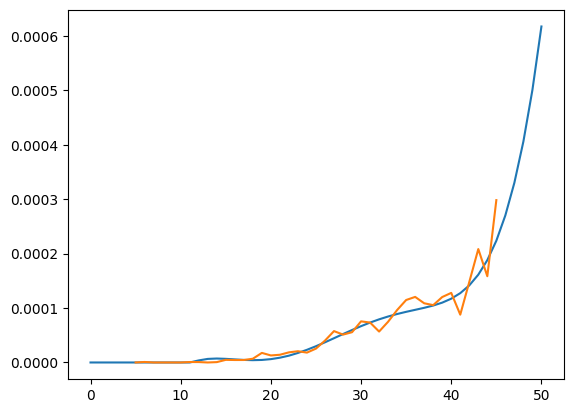

In [558]:
p_in = np.ones(51)*0.5

plt.plot(rescaler_scratch(p_in, bins))
plt.plot(counts_eq/counts_all)

## 4.3 Molcham on rescaled data

In [ ]:
sel1 = np.argwhere(np.isnan(bss_location))                                   # Everywhere
sel2 = np.argwhere(mot_baseline5 > 0)                                        # Where Baseline is available
sel3 = np.argwhere(np.logical_and(mot_baseline5>0, mot_tgt.sum(axis=0)>0))   # Where Baseline is available and an earthqauke occurs during testing
sel4 = np.argwhere(mot_tgt.sum(axis=0)>0)                                    # Where an earthquake occurs during testing

In [ ]:
def molchanize(sel, molcham_threshold_factors, n_bs=1000):
    md_mer = []
    md_fua = []
    md_mer_bs = []
    
    ix, iy = sel[:, 0], sel[:, 1]

    if ismodel49:
        scale_arr   = scale_from_neq_49(mot_neq)
    else:
        scale_arr  = scale_from_neq_boo(mot_neq)
        
    baseline_sel   = mot_baseline5[ix, iy]                # shape (N,)
    output_sel     = model_output[:, ix, iy]              # shape (M, N)
    scale_sel      = scale_arr[:, ix, iy]                 # shape (M, N)
    tgt_sel        = mot_tgt[:, ix, iy]
    
    md_mer_cc =   mot_tgt [:, ix, iy].sum()
    md_fua_cc =  (mot_tgt [:, ix, iy]+1).sum()
        
    for i, imtf in enumerate(molcham_threshold_factors):
        mpred = baseline_sel < output_sel * scale_sel * imtf
        md_mer_v = (~mpred[tgt_sel]).sum()
        
        tgt_bs = np.argwhere(tgt_sel)
        if i == 0:
            print(tgt_bs.shape[0])
        
        tgt_bs_sel = np.random.choice(tgt_bs.shape[0], size=(n_bs, tgt_sel.sum())).reshape(n_bs, -1)
        
        bs_x, bs_y = tgt_bs[tgt_bs_sel].reshape(-1, 2).T
    
        md_mer_bs_v = (~mpred[bs_x, bs_y]).reshape(n_bs, -1).sum(axis=1)
       
        md_fua_v = mpred.sum()
        
        print(f'Finished {i+1} of {len(molcham_threshold_factors)} Thresholds', end='\r')
        
        md_mer.append(md_mer_v/md_mer_cc)
        md_fua.append(md_fua_v/md_fua_cc)
        md_mer_bs.append(md_mer_bs_v/md_mer_cc)
    
    md_mer = np.array(md_mer)
    md_fua = np.array(md_fua)
    md_mer_bs_sort = np.sort(np.array(md_mer_bs), axis=-1)
    return md_mer, md_fua, md_mer_bs_sort


def report_fractional_sensitivity(data, mer_arr, fua_arr, mer_bs, X):
    idx = np.searchsorted(fua_arr, X)

    Xlab = str(int(X*100))

    data['AR'+Xlab]       = 100-mer_arr[idx  ]*100
    data['AR'+Xlab+'CIL'] = 100-mer_bs[idx  , int(mer_bs.shape[1]*0.975)]*100
    data['AR'+Xlab+'CIH'] = 100-mer_bs[idx  , int(mer_bs.shape[1]*0.025)]*100
        
    print(f'For {100*X:5.2f}% Area under Alarm:           ')
    print('Fraction under Alarm     Fraction of Detected Events')
    print(' '*12 + f'{fua_arr[idx-1]*100:5.2f}%   {100-mer_arr[idx-1]*100:5.2f}% [{100-mer_bs[idx-1, int(mer_bs.shape[1]*0.975)]*100:5.2f}-{100-mer_bs[idx-1, int(mer_bs.shape[1]*0.025)]*100:5.2f}]')
    print(' '*12 + f'{fua_arr[idx  ]*100:5.2f}%   {100-mer_arr[idx  ]*100:5.2f}% [{100-mer_bs[idx  , int(mer_bs.shape[1]*0.975)]*100:5.2f}-{100-mer_bs[idx  , int(mer_bs.shape[1]*0.025)]*100:5.2f}]')
    return data
    
def report_Molchan_AUC(data, mer_arr, fua_arr, mer_bs):

    auc     = np.trapz(mer_arr, x=fua_arr)
    auc_cil = np.trapz(mer_bs[:,int(mer_bs.shape[1]*0.025)], x=fua_arr)
    auc_cih = np.trapz(mer_bs[:,int(mer_bs.shape[1]*0.975)], x=fua_arr)
    
    print(f'AUC:   {auc:5.3f} [{auc_cil:5.3f} - {auc_cih:5.3f}]')

    data['AUC'] = auc
    data['AUCCIL'] = auc_cil
    data['AUCCIH'] = auc_cih
    
    return data

def add_stats_table(ax, data):
    blanks = '\n'.join(['x'*30]*3)
    
    stext = '\n'.join(
        [r'AR1  '+f'{data["AR1"    ]:5.2f}% [{data["AR1CIL"]:5.2f}% - {data["AR1CIH" ]:5.2f}%]',
         r'AR5  '+f'{data["AR5"    ]:5.2f}% [{data["AR5CIL"]:5.2f}% - {data["AR5CIH" ]:5.2f}%]',  
         'AUC   '    +f'{data["AUC"    ]:5.3f} [ {data["AUCCIL"]:5.3f} -  {data["AUCCIH" ]:5.3f}]'  ])
    
    fs = 5

    props = dict(boxstyle='round', facecolor='silver', alpha=0.5)
    ax.text(0.15, 0.87, blanks, color='none', transform=ax.transAxes, bbox=props, fontsize=fs)
    
    props = dict(boxstyle='square', facecolor='none', edgecolor='none')
    
    ax.text(0.15, 0.87, stext,  transform=ax.transAxes, bbox=props, fontsize=fs, family='monospace', ha='left')


In [ ]:
def make_molchan_diagram(sel, molcham_threshold_factors, name_ext, n_bs=1000):
    md_mer, md_fua, md_mer_bs_sort = molchanize(sel, molcham_threshold_factors, n_bs)

    data = {}
    data = report_fractional_sensitivity(data, md_mer, md_fua, md_mer_bs_sort, 0.01)
    data = report_fractional_sensitivity(data, md_mer, md_fua, md_mer_bs_sort, 0.05)
    data = report_Molchan_AUC(data, md_mer, md_fua, md_mer_bs_sort)
    
    fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=200)
    cmap = mpl.colormaps['jet']
    
    ax.scatter(md_fua, md_mer, c=cmap(np.linspace(0, 1, len(molcham_threshold_factors))), s=1)
    ax.plot([1, 0], [0, 1], ls=':', lw=0.5, color='silver')
    
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    ax.set_xlabel('Fraction of space–time under alarm')
    ax.set_ylabel('Fraction of missed target events')
    
    ax.set_title(r'$r_\mathrm{Model~Output} \cdot s_\mathrm{n_{EQ}} \cdot k > p_\mathrm{Baseline} $', fontsize=9)
    add_Molchan_colorbar(fig, ax, cmap, molcham_threshold_factors)
    
    plt.tight_layout()
    

    ax.plot(md_fua, md_mer_bs_sort[:, int(n_bs*0.025)], lw=0.5, color='silver')
    ax.plot(md_fua, md_mer_bs_sort[:, int(n_bs*0.975)], lw=0.5, color='silver')

    add_stats_table(ax, data)
    

def add_Molchan_colorbar(fig, ax, cmap, mtf, ox=0.03, oy=0.24, dx=0.03, dy=0.5, labelsize=6):
    axp = ax.get_position()
    ticks = np.linspace(np.log10(mtf).min(), np.log10(mtf).max(), int(np.log10(mtf).max()-np.log10(mtf).min())+1)
    axc = fig.add_axes([axp.x1-ox, axp.y0+oy, dx, dy])
    cb1 = mpl.colorbar.ColorbarBase(axc, cmap=cmap, orientation='vertical')
    cbticks = np.linspace(0, 1, int(len(ticks)/2+1))
    cb1.ax.get_yaxis().set_ticks(cbticks)
    cb1.ax.get_yaxis().set_ticklabels([f'$10^{{{int(np.round(i, 0)):+1d}}}$' for i in ticks if i%2==0])
    cb1.ax.yaxis.set_ticks_position('left')
    cb1.ax.tick_params(axis='y', labelsize=labelsize, pad=3)
    cb1.ax.set_ylabel(r'Threshold $k$', fontsize=8, x=-10)
    cb1.ax.yaxis.set_label_position('left')

In [ ]:
molcham_threshold_factors = np.logspace(-2, 10, 4000)

mot_neq = n_eq_avg[7302:7302+1456, 16:-16, 16:-16]

In [ ]:
make_molchan_diagram(sel2, molcham_threshold_factors, 'SEL2', n_bs=10000)

# 5. Extra Methodology Figures

## 5.1 Catalog Completeness Analysis
Godano Style test

In [59]:
def sample_cmap(name, x):
    cmap = plt.get_cmap(name)
    positions = np.linspace(0, 1, x)
    return [cmap(p) for p in positions]

In [55]:
npzfile = np.load(masterdir + 'Japan_ISC.npz', allow_pickle=True)
catalog_mag = npzfile['mag']
catalog_dat = npzfile['dat']
catalog_lon = npzfile['lon']
catalog_lat = npzfile['lat']
catalog_dep = npzfile['dep']

In [56]:
def get_ma(mags):
    return np.array([mags[mags>mth].mean() for mth in mbin])

In [63]:
sel = np.logical_and(
        np.logical_and(
            np.logical_and(catalog_lat >= 35, catalog_lat <= 46, ),
            np.logical_and(catalog_lon >=135, catalog_lon <= 146, )
        ),
        np.logical_and(
            np.logical_and(catalog_dep == catalog_dep, catalog_dep <= 70000, ),
            np.logical_and(catalog_dat >= np.datetime64('2020-01-01'), catalog_dat < np.datetime64('2024-01-01'), )
        )
)

/tmp/ipykernel_730107/1487193997.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap('viridis', nbins)
/tmp/ipykernel_730107/1421371482.py:2: RuntimeWarning: Mean of empty slice.
  return np.array([mags[mags>mth].mean() for mth in mbin])
/home/jkoehler/ENVS/forecasting_venv/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


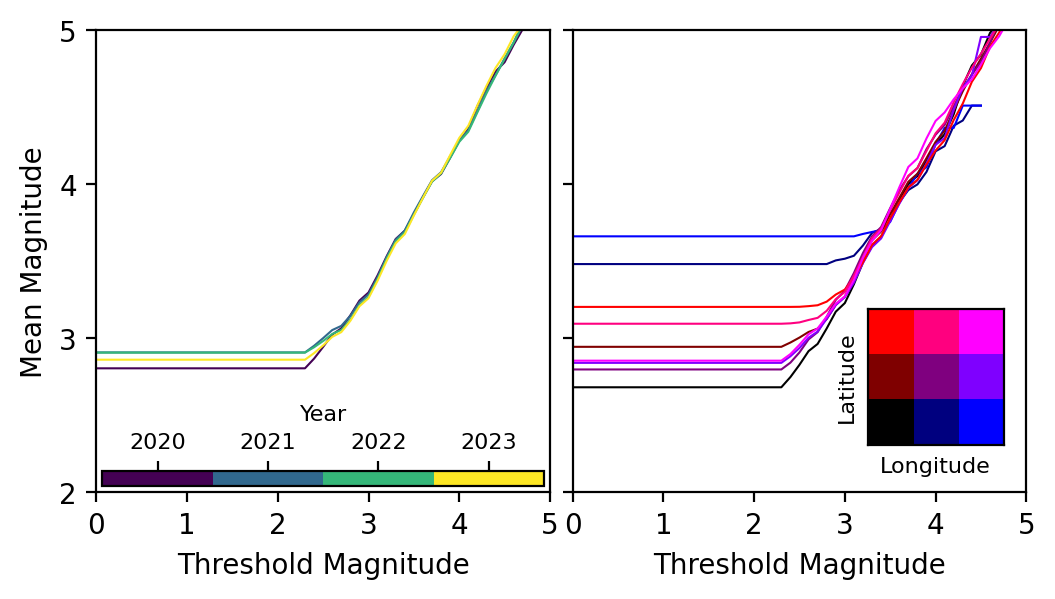

In [64]:
fig, ax = plt.subplots(1,2, figsize=(6,3), dpi=200, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05)
mbin = np.arange(0, 10.1, 0.1)

nbins = 4
colors = sample_cmap('viridis', nbins)

cmap = mpl.cm.get_cmap('viridis', nbins)

for i, y in enumerate(range(2020, 2024)):
    sel2 = catalog_dat.astype('datetime64[Y]').astype(int)+1970 == y
    ax[0].plot(mbin, get_ma(catalog_mag[np.logical_and(sel, sel2)]), lw=0.75, color=colors[i])


axp = ax[0].get_position().x1
axc = fig.add_axes([ax[0].get_position().x0+0.005, ax[0].get_position().y0+0.01, ax[0].get_position().x1 - ax[0].get_position().x0-0.01, 0.025])
cb1 = mpl.colorbar.ColorbarBase(axc, cmap=cmap, orientation='horizontal')
cb1.ax.xaxis.tick_top()      
cb1.ax.xaxis.set_label_position("top") 

cbticks = np.linspace(0, 1, nbins+1)
cbticks = (cbticks[1:] + cbticks[:-1])/2
cb1.ax.get_xaxis().set_ticks(cbticks)
cbticklabels = [str(y) for y in range(2020, 2024)]
cb1.ax.get_xaxis().set_ticklabels(cbticklabels, fontsize=8)
cb1.ax.set_xlabel(r'Year', fontsize=8)


grid = 3
color_grid = np.zeros((grid, grid, 3))
for x in range(grid):
    for y in range(grid):
        x1, x2 = (11/grid)*x, (11/grid)*(x+1)
        y1, y2 = (11/grid)*y, (11/grid)*(y+1)
        
        sel2 = np.logical_and(
                np.logical_and(catalog_lat >=  35+y1, catalog_lat <=  35+y2 ),
                np.logical_and(catalog_lon >= 135+x1, catalog_lon <= 135+x2 ))
        
        ax[1].plot(mbin, get_ma(catalog_mag[np.logical_and(sel, sel2)]), lw=0.75, color=(x/(grid-1), 0, y/(grid-1)))
        color_grid[x, y] = [x / (grid-1), 0,  y / (grid-1)]

axins = ax[1].inset_axes([0.65, 0.1, 0.3, 0.3])
axins.imshow(color_grid, origin='lower')
axins.set_xlabel('Longitude', fontsize=8)
axins.set_ylabel('Latitude', fontsize=8)
axins.set_xticks([])
axins.set_yticks([])

ax[0].set_xlim([0, 5])
ax[0].set_ylim([2, 5])
ax[0].set_yticks(np.arange(2, 5.1, 1))
ax[0].set_xticks(np.arange(0, 5.1, 1))

for a in ax:
    a.set_xlabel('Threshold Magnitude')
ax[0].set_ylabel('Mean Magnitude')



## 5.2 Completeness for ETAS

In [ ]:
def get_ma(mags):
    return np.array([mags[mags>mth].mean() for mth in mbin])


completeness = np.zeros((110, 110))*np.nan
mbin = np.arange(1, 5.01, 0.1)

sel_t = np.logical_and(
            np.logical_and(catalog_dep == catalog_dep, catalog_dep <= 70000, ),
            np.logical_and(catalog_dat >= np.datetime64('2020-01-01'), catalog_dat < np.datetime64('2024-01-01'), )
        )
t0 = time.time()
for ix, cx in enumerate(np.arange(135.05, 146.01, 0.1)):
    for iy, cy in enumerate(np.arange(35.05, 46.01, 0.1)):

        sel = np.logical_and(((catalog_lat  - cy)**2 + (catalog_lon  - cx)**2) <= 0.6, sel_t)
        ma = get_ma(catalog_mag[sel])
        finx = np.argwhere(ma > (ma[0] + 0.2))
        if len(finx) == 0:
            completeness[ix, iy] = np.nan
        else:
            completeness[ix, iy] = mbin[finx[0]]
        t1 = time.time()
        trem = int((t1-t0) / (ix*110 + iy+1) * (110*110 - (ix*110 + iy + 1)))
        print(f'ix: {ix:>3d} iy:{iy:>3d}  Remaining Time: {trem:>4d}s', end='\r')

In [22]:
with open('P2_ETAS_Completeness_P2.npy', 'wb') as f:
    np.save(f, completeness)

In [99]:
completeness = np.load('P2_ETAS_Completeness_P2.npy')

In [100]:
print(f'Min: {np.nanmin(completeness)}   Max:{np.nanmax(completeness)}')

Min: 2.5000000000000013   Max:4.200000000000003


Placing 130 events in the area
Placing 625 events outside the area


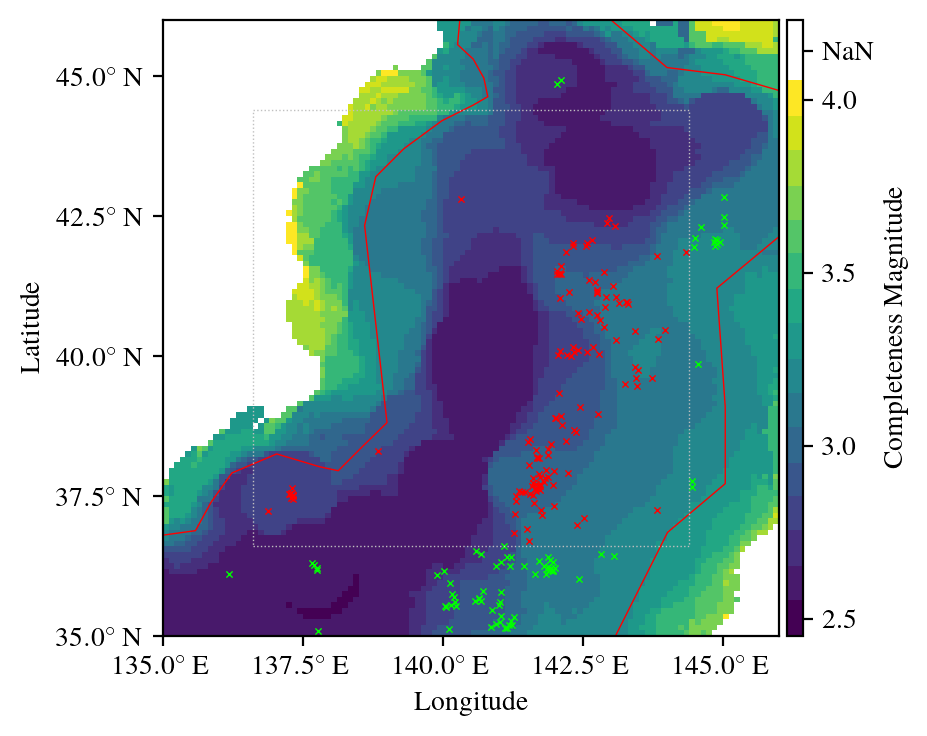

In [104]:
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=200)
coords = [35, 46, 135, 146]

cmap = 'viridis'
norm = mpl.colors.Normalize(vmin=2.5, vmax=4.0)
cmap_im = plt.get_cmap(cmap)
cmap_im.set_bad('white',1.)
ax.imshow(completeness.T, origin='lower', norm=norm, cmap=cmap, extent=[135, 146, 35, 46])

sel = np.logical_and(
        np.logical_and(
            np.logical_and(catalog_lat >=  35+1.6, catalog_lat <=  46-1.6),
            np.logical_and(catalog_lon >= 135+1.6, catalog_lon <= 146-1.6)
        ),
        np.logical_and(
            np.logical_and(catalog_mag >= 5.0, catalog_dep <= 70000, ),
            np.logical_and(catalog_dat >= np.datetime64('2020-01-01'), catalog_dat < np.datetime64('2024-01-01'), )
        )
)

sel2 = np.logical_and(
        np.logical_or(
            np.logical_or(catalog_lat <=  35+1.6, catalog_lat >=  46-1.6),
            np.logical_or(catalog_lon <= 135+1.6, catalog_lon >= 146-1.6)
        ),
        np.logical_and(
            np.logical_and(catalog_mag >= 5.0, catalog_dep <= 70000, ),
            np.logical_and(catalog_dat >= np.datetime64('2020-01-01'), catalog_dat < np.datetime64('2024-01-01'), )
        )
)

print(f'Placing {sel.sum()} events in the area')
print(f'Placing {sel2.sum()} events outside the area')

ax.scatter(catalog_lon[sel], catalog_lat[sel], marker='x', color='r', lw=0.5, s=5)
ax.scatter(catalog_lon[sel2], catalog_lat[sel2], marker='x', color='lime', lw=0.5, s=5)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.set_xlim([coords[2], coords[3]])
ax.set_ylim([coords[0], coords[1]])

xticks = np.arange(135, 146, 2.5)
yticks = np.arange(35, 46, 2.5)
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels([fr'${tick}^\circ$ E' for tick in xticks])
ax.set_yticklabels([fr'${tick}^\circ$ N ' for tick in yticks])
ax.set_xlabel(r'Longitude')
ax.set_ylabel(r'Latitude')


def CBPlacer(ax):
    x0 = ax.get_position().x1+0.01
    x1 = 0.02
    y0 = ax.get_position().y0
    y1 = ax.get_position().y1-y0
    return [x0, y0, x1, y1]

axc = fig.add_axes(CBPlacer(ax))


def viridis_with_white_tail(frac_white=0.05, n=256, N=16):
    base = plt.get_cmap(cmap)
    base = mpl.colors.LinearSegmentedColormap.from_list('viridis_discrete', base(np.linspace(0, 1, N)), N=N)
    n_white = int(n * frac_white)
    n_color = n - n_white
    colors = np.vstack([
        base(np.linspace(0, 1, n_color)),
        np.ones((n_white, 4))
    ])
    return mpl.colors.ListedColormap(colors)

cmap_cb = viridis_with_white_tail(frac_white=0.1)

cb1 = mpl.colorbar.ColorbarBase(axc, cmap=cmap_cb)
cb1.set_label(r'Completeness Magnitude', labelpad=3)
cbticks = list(1/3.56 * np.arange(4)+0.028) + [0.95]
cblabels = ['2.5','3.0','3.5','4.0', 'NaN']
cb1.ax.get_yaxis().set_ticks(cbticks)
cb1.ax.set_yticklabels(cblabels)

polygon2 = np.array([
    [136.6, 36.6],
    [144.4, 36.6],
    [144.4, 44.4],
    [136.6, 44.4],
    [136.6, 36.6],
])



polygon = np.array([[135.00, 36.80],
[135.58, 36.88],
[135.86, 37.39],
[136.23, 37.91],
[137.03, 38.25],
[137.80, 38.02],
[138.13, 37.95],
[138.56, 38.38],
[139., 38.81],
[138.6, 42.33],
[138.8, 43.20],
[139.3, 43.7],
[139.98, 44.20],
[140.54, 44.48],
[140.80, 44.63],
[140.73, 44.96],
[140.54, 45.30],
[140.26, 45.56],
[140.30, 46.00],
[143.00, 46.00],
[144.00, 45.15],
[145.04, 45.02],
[146.00, 44.74],
[146.00, 42.13],
[144.89, 41.21],
[145.04, 39.09],
[145.04, 37.72],
[144.01, 36.85],
[143.08, 35.00],
[135.00, 35.00],
[135.00, 36.80]])


ax.plot(polygon[:, 0], polygon[:, 1], lw=0.5, color='r')
ax.plot(polygon2[:, 0], polygon2[:, 1], lw=0.5, color='silver', ls=':')

# 6. Paper 2 Stuff
## 6.1 Preparation for the ETAS Analysis

In [18]:
npzfile = np.load(masterdir + 'Japan_ISC.npz', allow_pickle=True)
catalog_mag = npzfile['mag']
catalog_dat = npzfile['dat']
catalog_lon = npzfile['lon']
catalog_lat = npzfile['lat']
catalog_dep = npzfile['dep']

In [19]:
sel_etas = np.logical_and(
        np.logical_and(
            np.logical_and(catalog_lat >= 31, catalog_lat <= 50),
            np.logical_and(catalog_lon >=131, catalog_lon <= 150)
        ),
        np.logical_and(
            np.logical_and(catalog_mag >= 3.3, catalog_dep <= 70000),
            np.logical_and(catalog_dat >= np.datetime64('2018-01-01'), catalog_dat < np.datetime64('2025-01-01'))
        )
)

print(f'ETAS set: {sel_etas.sum()}')

ETAS set: 107397


In [20]:
ids = np.arange(sel_etas.sum())
lats = catalog_lat[sel_etas]
lons = catalog_lon[sel_etas]
times = catalog_dat[sel_etas].astype(str)
mags = catalog_mag[sel_etas].round(1)


data = np.column_stack((ids, lats, lons, times, mags))
ptimes = times.astype('datetime64[D]').astype(int) - np.datetime64('2020-01-01').astype(int)


## 6.2 ETAS Results Analysis

In [25]:
etas_data = np.genfromtxt('yourpathtotheetasdicrectorygoeshere/output/trig_and_bg_probs_0.csv', delimiter=',')

In [28]:
etas_data[1:, 4] = data[etas_data[1:, 0].astype(int), 4]
sel_md = np.logical_and(
            np.logical_and(
                np.logical_and(etas_data[:, 1] >=  35+1.6, etas_data[:, 1] <=  46-1.6),
                np.logical_and(etas_data[:, 2] >= 135+1.6, etas_data[:, 2] <= 146-1.6)),
            np.logical_and(etas_data[:,4] >= 5.0, etas_data[:, 0] > 26464)
)

etas_data[1:, 3] = data[etas_data[1:, 0].astype(int), 3].astype('datetime64[D]') - np.datetime64('2020-01-01').astype(int)

etas_events = etas_data[sel_md].astype(object)

In [30]:
etas_events[:, 0] = etas_events[:, 0].astype(int)
etas_events[:, 3] = data[etas_events[:, 0].astype(int), 3]


In [31]:
days = (etas_events[:, 3].astype('datetime64[D]') - np.datetime64('2020-01-01')).astype(int)


In [35]:
dual_output = []
for i, day in enumerate(np.argwhere(maxm_loc[7306:7306+1456, 16:-16, 16:-16] >= 5.0)[:, 0]):
    arg = np.argwhere(np.logical_and(day == days, etas_events[:, 4].astype(np.float16) == model_mags.astype(np.float16)[i].round(1)))[0]
    dual_output.append([
        etas_events[:, 9][arg][0], 
        model_outputs[i], 
        model_mags[i],
        (etas_events[:, 7][arg]/etas_events[:, 9][arg])[0]
    ])

dual_output = np.array(dual_output)

In [34]:
with open('results_validmagneq_P2.pkl', 'rb') as filehandler:
    results_validmagneq_real = pickle.load(filehandler)

model_outputs = []
model_mags = []

for i in results_validmagneq_real:
    if len(i[1]) == 1:
        model_outputs.append(i[1][0].item())
    else:
        model_outputs.extend(i[1])
    model_mags.extend(i[2])
model_mags = np.array([i.item() for i in model_mags])
model_outputs = np.array(model_outputs)

In [77]:
import scipy.stats
tm = lambda x : np.log((x+1e-8) / (1 - x +1e-8))

def get_logitlogit_CI(x, y):
    n_samples = len(x)
    res = []
    res_pearson = []
    res_spearman = []
    for i in range(10000):
        bsinx = np.random.randint(low=0, high=n_samples, size=n_samples)
        res.append(scipy.stats.linregress(x[bsinx], y[bsinx]))
        res_spearman.append(scipy.stats.spearmanr(x[bsinx], y[bsinx]).statistic)
        res_pearson.append(scipy.stats.pearsonr(x[bsinx], y[bsinx]).statistic)

    return np.array(res), np.array(res_spearman), np.array(res_pearson)

def make_CI_plot(res, x, ax):
    lower = []
    upper = []
    for xi in x:
        per = np.percentile(res[:, 0]*xi + res[:, 1], [2.5, 97.5])
        lower.append(per[0])
        upper.append(per[1])
        
    ax.fill_between(x, lower, upper, alpha=0.3, zorder=-1)

CI, CI_p, CI_s = get_logitlogit_CI(tm(dual_output[:, 0]), tm(dual_output[:, 1]))

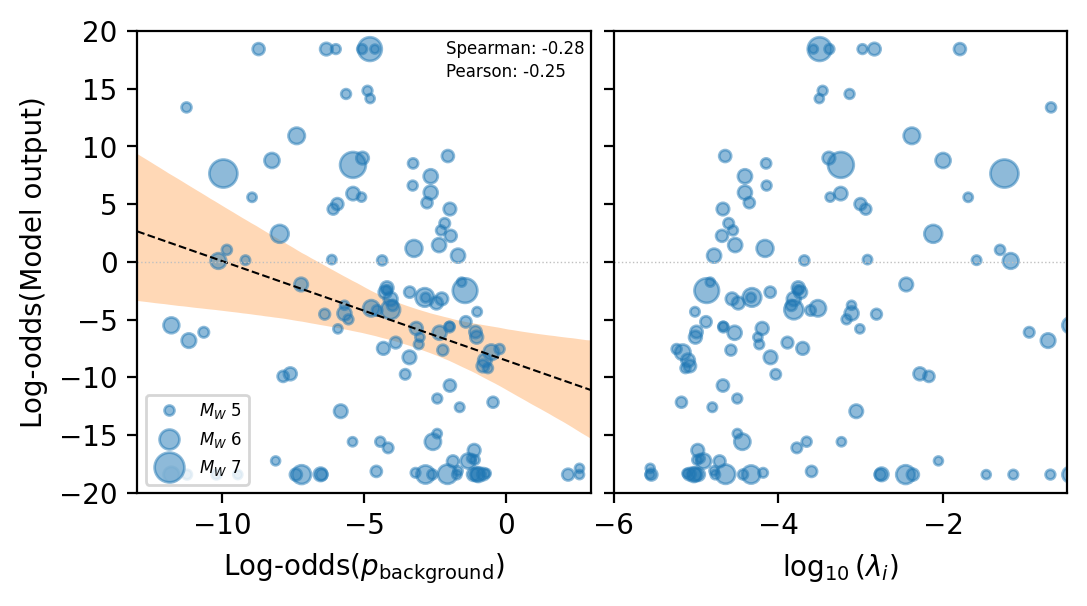

In [61]:
fig, ax = plt.subplots(1,2, figsize=(6, 3), sharey=True, dpi=200)
plt.subplots_adjust(wspace=0.05)

sf = lambda s: 10*(s-4.0)**2
cf = lambda s: np.sqrt(4 * s / np.pi)



ax[0].scatter(tm(dual_output[:, 0]), tm(dual_output[:, 1]), s=sf(dual_output[:, 2]), alpha=0.5)

res = scipy.stats.linregress(tm(dual_output[:, 0]), tm(dual_output[:, 1]))

tl = lambda x: res.intercept + x*res.slope
x = np.linspace(-13, 3, 100)
make_CI_plot(CI, x, ax[0])
ax[0].plot(x, tl(x), lw=0.75, c='k', ls='--')
ax[0].set_xlim([-13, 3])

ax[0].set_ylabel('Log-odds(Model output)')
ax[0].set_xlabel(r'Log-odds$(p_\mathrm{background})$')

for a in ax:
    a.axhline(0, lw=0.5, ls=':', color='silver')

ax[1].scatter(np.log10(dual_output[:, 3]), tm(dual_output[:, 1]), s=sf(dual_output[:, 2]), alpha=0.5)
ax[1].set_xlabel(r'$\log_{10}(\lambda_i)$')
ax[0].text(0.68, 0.95, fr'Spearman: {scipy.stats.spearmanr(tm(dual_output[:, 0]), tm(dual_output[:, 1])).statistic:4.2f}', transform=ax[0].transAxes, fontsize=6)
ax[0].text(0.68, 0.90, fr'Pearson: {scipy.stats.pearsonr(tm(dual_output[:, 0]), tm(dual_output[:, 1])).statistic:4.2f}', transform=ax[0].transAxes, fontsize=6)

handles = [plt.Line2D([0], [0], lw=0, marker='o', alpha=0.5, markersize=cf(sf(s)), label=fr'$M_W \ {s}$') for s in [5,6,7]]
ax[0].legend(loc='lower left', handles=handles, fontsize=6)
ax[0].set_ylim([-20, 20])
ax[1].set_xlim([-6, -0.5])


In [38]:
sel_ov = np.logical_and(
        np.logical_and(
            np.logical_and(catalog_lat >= 35, catalog_lat <=  46),
            np.logical_and(catalog_lon >=135, catalog_lon <= 146)
        ),
        np.logical_and(
            np.logical_and(catalog_mag < 3.7, catalog_dep <= 70000),
            np.logical_and(catalog_dat >= np.datetime64('2020-01-01'), catalog_dat < np.datetime64('2023-01-01'))
        )
)

days_ov = ((catalog_dat.astype('datetime64[D]') - np.datetime64('2020-01-01')).astype(int))[sel_ov]
mag_ov = catalog_mag[sel_ov]


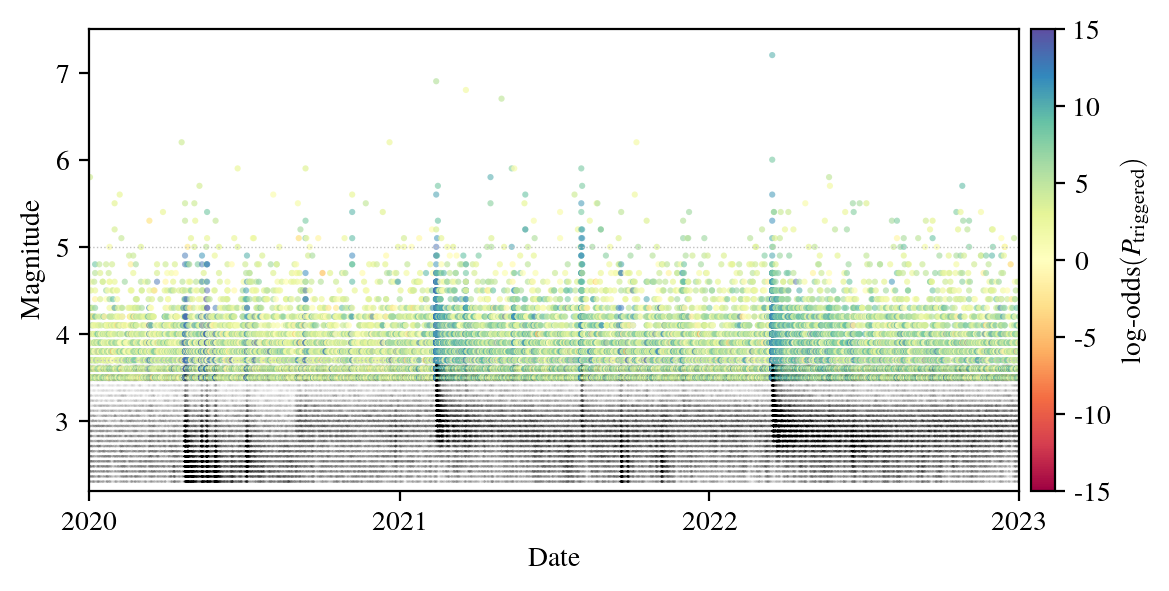

In [106]:
fig, ax = plt.subplots(1, figsize=(6,3), dpi=200, sharey=True)

cmap = plt.get_cmap('Spectral')

ta = lambda x: np.sqrt(1-x*0.8)
tm = lambda x : np.log((x+1e-8) / (1 - x + 1e-8))
tc = lambda x: np.clip(x, -15, 15)/30+0.5
etas_data[1:, 8]


ax.scatter(etas_data[1:, 3], etas_data[1:, 4], alpha=ta(tc(tm(etas_data[1:, 8]))), s=5, color=cmap(tc(tm(etas_data[1:, 8]))), edgecolors='none', rasterized=True)
ax.scatter(days_ov, mag_ov, alpha=0.01, s=1, color='k', edgecolors='none', rasterized=True)

ax.axhline(5.0, lw=0.5, ls=':', color='silver')
ax.axhline(3.7, lw=0.5, ls=':', color='silver')

ax.set_xlabel(r'Date')
ax.set_xticks([0, 366, 731, 1096])
ax.set_xticklabels([2020, 2021, 2022, 2023])

ax.set_ylabel(r'Magnitude')



def CBPlacer(ax):
    x0 = ax.get_position().x1+0.01
    x1 = 0.02
    y0 = ax.get_position().y0
    y1 = ax.get_position().y1-y0
    return [x0, y0, x1, y1]

axc = fig.add_axes(CBPlacer(ax))

cb1 = mpl.colorbar.ColorbarBase(axc, cmap=cmap)
cb1.set_label(r'log-odds$(P_\mathrm{triggered})$', labelpad=3)
cbticks = np.linspace(0,1,7)
cblabels = np.linspace(-15, 15, 7)
cb1.ax.get_yaxis().set_ticks(cbticks)
cb1.ax.set_yticklabels([f'{int(cbl)}' for cbl in cblabels])
ax.set_xlim([0, 1096])
ax.set_ylim([2.2, 7.5])